**Навигация по уроку**

1. [Простые нейронные сети. Знакомство с библиотекой Keras](https://colab.research.google.com/drive/16xfRAdyg-Re1bP2cyYpbpAALa6noUL3U)
2. [Распознание рукописных цифр (Практика)](https://colab.research.google.com/drive/1RaGkCutdIazFN5PtQOod5UH2Cc05diYI)
3. Домашняя работа

Используя датасет по рукописным буквам английского языка, обучите модель, оцените ее предсказательные способности. Используйте только полносвязанные слои. Поэкспериментируйте с числом слоев и числом нейронов в слое, добейтесь максимальной точности. Используйте куски кода и рекомендации из практической части урока. Нарисуйте графики точности и потерь для обучающей и тестовой выборки, сделайте по ним выводы.

Оценка за задание:
* 1 балл - задача решена с помощью куратора, точность на проверочной выборке ниже 85%
* 2 балла - задача решена с подсказками куратора, точность на проверочной выборке выше 85%
* 3 балла - задача решена самостоятельно, точность на проверочной выборке выше 85%
* 4 балла - задача решена самостоятельно, точность на проверочной выборке выше 93%
* 5 баллов - задача решена самостоятельно, точность на проверочной выборке выше 97%

In [ ]:
import numpy as np
dataset = np.loadtxt('https://storage.yandexcloud.net/academy.ai/A_Z_Handwritten_Data.csv', delimiter=',')

In [ ]:
X = dataset[:,1:785]
Y = dataset[:,0]

In [ ]:
from sklearn.model_selection import train_test_split
(x_train, x_test, y_train, y_test) = train_test_split(X, Y, test_size=0.2, shuffle=True)

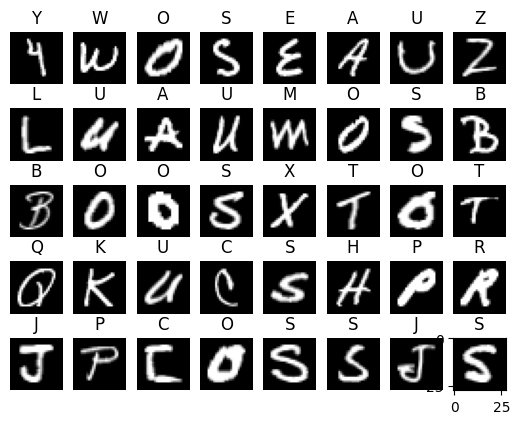

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

word_dict = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X',24:'Y',25:'Z'}

for i in range(40):
    x = x_train[i]
    x = x.reshape((28, 28))
    plt.axis('off')
    im = plt.subplot(5, 8, i+1)
    plt.title(word_dict.get(y_train[i]))
    im.imshow(x, cmap='gray')


In [ ]:
pip install keras

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 103s 11ms/step - accuracy: 0.9026 - loss: 0.3428 - val_accuracy: 0.9666 - val_loss: 0.1160
Epoch 2/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 97s 10ms/step - accuracy: 0.9712 - loss: 0.0974 - val_accuracy: 0.9737 - val_loss: 0.0903
Epoch 3/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 146s 11ms/step - accuracy: 0.9795 - loss: 0.0689 - val_accuracy: 0.9767 - val_loss: 0.0857
Epoch 4/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 105s 11ms/step - accuracy: 0.9830 - loss: 0.0559 - val_accuracy: 0.9784 - val_loss: 0.0784
Epoch 5/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 137s 11ms/step - accuracy: 0.9850 - loss: 0.0498 - val_accuracy: 0.9810 - val_loss: 0.0708
Epoch 6/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - accuracy: 0.9876 - loss: 0.0424 - val_accuracy: 0.9809 - val_loss: 0.0852
Epoch 7/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 141s 11ms/step - accuracy: 0.9883 - loss: 0.0400 - val_accuracy: 0.9822 - val_loss: 0.0765
Epoch 8/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - accuracy: 0

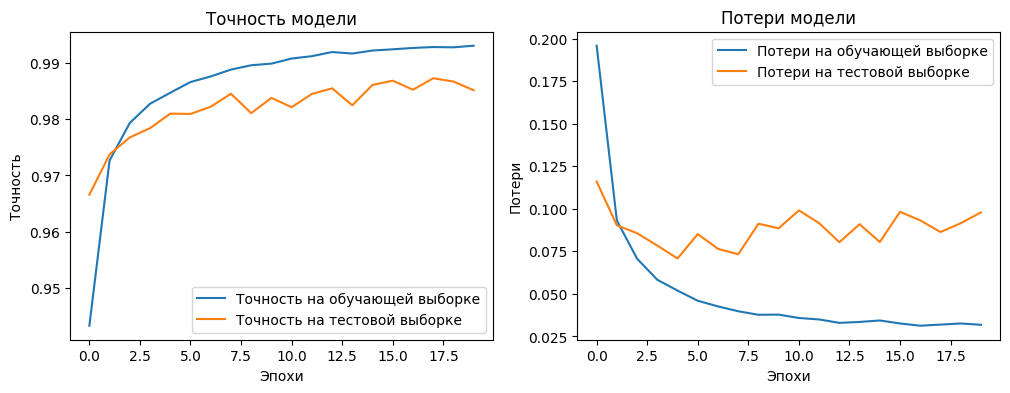

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical

# Загрузка данных
dataset = np.loadtxt('https://storage.yandexcloud.net/academy.ai/A_Z_Handwritten_Data.csv', delimiter=',')
X = dataset[:, 1:785]
Y = dataset[:, 0]

# Разделение на обучающую и тестовую выборки
(x_train, x_test, y_train, y_test) = train_test_split(X, Y, test_size=0.2, shuffle=True)

# Нормализация данных
x_train = x_train / 255.0
x_test = x_test / 255.0

# Преобразование меток в категориальный формат
y_train = to_categorical(y_train, num_classes=26)
y_test = to_categorical(y_test, num_classes=26)

# Создание модели
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))  # Первый скрытый слой
model.add(Dense(256, activation='relu'))                       # Второй скрытый слой
model.add(Dense(128, activation='relu'))                       # Третий скрытый слой
model.add(Dense(26, activation='softmax'))                     # Выходной слой

# Компиляция модели
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Обучение модели
history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test))

# Визуализация точности и потерь
plt.figure(figsize=(12, 4))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Точность на обучающей выборке')
plt.plot(history.history['val_accuracy'], label='Точность на тестовой выборке')
plt.title('Точность модели')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

# График потерь
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Потери на обучающей выборке')
plt.plot(history.history['val_loss'], label='Потери на тестовой выборке')
plt.title('Потери модели')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()

plt.show()


Выводы по результатам обучения модели

Общая точность: Модель демонстрирует высокую точность на обучающей выборке, достигая 99.34% на 20-й эпохе.

Потери: Значение потерь (loss) на обучающей выборке постепенно уменьшается, начиная с 0.3428 и достигая 0.0299 к концу обучения.

Валидация: Валидационная точность также остается высокой, достигая 98.72% на 18-й эпохе, но немного колеблется в последние эпохи. Это указывает на небольшую переобученность из за количества эпох.
